# 118 - 埋め込み空間特性レポート: 異方性・Two-tower・ANN 性能

## 目的

NB115-117 の HNSW/Voronoi 比較実験で、**モダリティ**が ANN 性能に大きく影響することが判明した。
本レポートでは 3 モデル × 5 埋め込み空間について、**異方性・等方性・Two-tower 構造** を体系的に分析し、
それらが検索性能とどう関連するかを考察する。

### NB115-117 の発見
- **テキスト→画像 (NB115)**: HNSW `ef=16` で BF-R@10=0.667（クロスモーダル）
- **画像→画像 (NB116)**: HNSW `ef=16` で BF-R@10=0.850（同一モダリティ）
- **顔→顔 (NB117)**: HNSW `ef=16` で BF-R@10=**0.967**（同一モダリティ、強いクラスタ）

**仮説**: 異方性よりも **モダリティマッチ + データ分布の局所密度** が ANN 性能を決める

### 分析対象（5 埋め込み空間 × 3 モデル）
| モデル | 構造 | 画像タワー | テキストタワー | 学習損失 |
|--------|------|:---:|:---:|--------|
| SigLIP 2 Large | Dual Encoder | 1024-D | 1024-D | Sigmoid |
| CLIP-L | Dual Encoder | 768-D | 768-D | Contrastive |
| ArcFace (buffalo_l) | Single Tower | 512-D (顔のみ) | - | Arc-margin Softmax |

In [1]:
import sys
sys.path.insert(0, '../src')

import json
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from image_vector_poc.search.lsh.whitening import compute_isotropy_score

DB_PATH = Path('../data/images.duckdb')
SIGLIP2_LARGE_DB = Path('/home/terapyon/dev/vibe-coding/pyconjp-image-search/pyconjp_image_search_siglip2_large.duckdb')


def participation_ratio(eigenvalues):
    """Participation Ratio（有効次元数）= (Σλ)² / Σλ²"""
    lam = np.array(eigenvalues, dtype=np.float64)
    lam = lam[lam > 0]
    return (lam.sum() ** 2) / (lam ** 2).sum()


def extended_isotropy(embeddings):
    """compute_isotropy_score の結果に PR と固有値を追加。"""
    base = compute_isotropy_score(embeddings)
    centered = embeddings - np.mean(embeddings, axis=0)
    cov = np.cov(centered.T)
    eigs = np.linalg.eigvalsh(cov)
    eigs = np.sort(eigs)[::-1]
    eigs = eigs[eigs > 0]
    base['participation_ratio'] = float(participation_ratio(eigs))
    base['effective_dim_ratio'] = base['participation_ratio'] / embeddings.shape[1]
    base['n_samples'] = len(embeddings)
    base['dim'] = embeddings.shape[1]
    return base, eigs

## 1. データ読み込み

In [2]:
# SigLIP 2 Large 画像（23K: catalog + pyconjp）
conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute('LOAD vss;')
sl2_catalog = conn.execute("""
    SELECT embedding FROM image_embeddings_1024
    WHERE model_name = 'google/siglip2-large-patch16-256'
""").fetchall()
clip_catalog = conn.execute("""
    SELECT embedding FROM image_embeddings_768
    WHERE model_name = 'openai/clip-vit-large-patch14'
""").fetchall()
conn.close()

conn_pj = duckdb.connect(str(SIGLIP2_LARGE_DB), read_only=True)
sl2_pyconjp = conn_pj.execute("""
    SELECT embedding FROM image_embeddings
    WHERE model_name = 'google/siglip2-large-patch16-256'
""").fetchall()
conn_pj.close()

sl2_images = np.array(
    [[float(x) for x in r[0]] for r in sl2_catalog] +
    [[float(x) for x in r[0]] for r in sl2_pyconjp],
    dtype=np.float32
)
sl2_images_normed = sl2_images / np.linalg.norm(sl2_images, axis=1, keepdims=True)

clip_images = np.array([[float(x) for x in r[0]] for r in clip_catalog], dtype=np.float32)
clip_images_normed = clip_images / np.linalg.norm(clip_images, axis=1, keepdims=True)

# 顔埋め込み
conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute('LOAD vss;')
face_rows = conn.execute("""
    SELECT embedding FROM face_detections
    WHERE model_name = 'insightface/buffalo_l'
""").fetchall()
conn.close()

face_embs = np.array([[float(x) for x in r[0]] for r in face_rows], dtype=np.float32)
face_embs_normed = face_embs / np.linalg.norm(face_embs, axis=1, keepdims=True)

print(f'SigLIP 2 Large 画像: {sl2_images_normed.shape}')
print(f'CLIP-L 画像:        {clip_images_normed.shape}')
print(f'ArcFace 顔:         {face_embs_normed.shape}')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

SigLIP 2 Large 画像: (23464, 1024)
CLIP-L 画像:        (378, 768)
ArcFace 顔:         (75162, 512)


In [3]:
# テキスト埋め込みの生成（統計的に十分な数のテキスト）
import torch
from image_vector_poc import SigLIP2Embedder
from image_vector_poc.embeddings.clip import CLIPEmbedder

# NB115 の 18 クエリ + 追加の一般テキストコーパスで統計を取る
text_corpus = [
    'a park with trees and nature', 'village park with greenery',
    'night cityscape Tokyo', 'city lights at night',
    'Python conference presentation', 'conference hall with audience',
    'speaker giving a talk', 'portrait photo of a person',
    'outdoor nature scene', 'urban night photography',
    'tech conference event', 'people at an event',
    '公園の自然風景', '東京の夜景', 'カンファレンスの講演',
    '人物の写真', '緑の木々', '夜の街',
    # 追加のテキスト（統計量向上のため）
    'a dog playing in the park', 'a cat sitting on a chair',
    'sunset over the ocean', 'mountain landscape',
    'food on a plate', 'coffee cup on a table',
    'building architecture', 'car on the road',
    'flower garden', 'river and bridge',
    'beach with sand', 'forest in autumn',
    'snow covered mountain', 'clouds in the sky',
    'book on a desk', 'laptop computer',
    'children playing', 'people walking on the street',
    'train station', 'airport terminal',
    'museum exhibit', 'art gallery',
    'sports game', 'concert hall',
    '犬が公園で遊ぶ', '猫が椅子に座る',
    '海に沈む夕日', '山の景色', '料理の写真', 'コーヒーカップ',
    '建築物', '道路を走る車', '花の庭', '川と橋',
    '砂浜', '秋の森', '雪山', '空の雲', '机の本', 'ノートパソコン',
    '子供が遊ぶ', '街を歩く人々', '駅', '空港',
]
print(f'テキストコーパス: {len(text_corpus)} 文')

# SigLIP 2 テキスト
sl2_embedder = SigLIP2Embedder(model_name='google/siglip2-large-patch16-256', device='cuda')
sl2_texts = sl2_embedder.embed_texts(text_corpus)
sl2_texts_normed = sl2_texts / np.linalg.norm(sl2_texts, axis=1, keepdims=True)
del sl2_embedder
torch.cuda.empty_cache()
print(f'SigLIP 2 テキスト: {sl2_texts_normed.shape}')

# CLIP-L テキスト
clip_embedder = CLIPEmbedder(model_name='openai/clip-vit-large-patch14', device='cuda')
clip_texts = clip_embedder.embed_texts(text_corpus)
clip_texts_normed = clip_texts / np.linalg.norm(clip_texts, axis=1, keepdims=True)
del clip_embedder
torch.cuda.empty_cache()
print(f'CLIP-L テキスト:   {clip_texts_normed.shape}')

テキストコーパス: 62 文


Loading weights:   0%|          | 0/792 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


SigLIP 2 テキスト: (62, 1024)


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


CLIP-L テキスト:   (62, 768)


## 2. 各埋め込み空間の異方性分析

In [4]:
# 5 つの埋め込み空間の isotropy を計算
spaces = {
    'SigLIP2-L image': sl2_images_normed,
    'SigLIP2-L text': sl2_texts_normed,
    'CLIP-L image': clip_images_normed,
    'CLIP-L text': clip_texts_normed,
    'ArcFace face': face_embs_normed,
}

isotropy_results = {}
eigenvalues_dict = {}

for name, embs in spaces.items():
    metrics, eigs = extended_isotropy(embs)
    isotropy_results[name] = metrics
    eigenvalues_dict[name] = eigs
    print(f'{name:<20}: n={metrics["n_samples"]:>6}, dim={metrics["dim"]:>5}, '
          f'cond#={metrics["condition_number"]:>10.1f}, '
          f'top10_var={metrics["top10_variance_ratio"]:>6.4f}, '
          f'PR={metrics["participation_ratio"]:>7.2f} '
          f'({metrics["effective_dim_ratio"]*100:>5.1f}%)')

SigLIP2-L image     : n= 23464, dim= 1024, cond#=  845706.2, top10_var=0.3916, PR=  42.08 (  4.1%)


SigLIP2-L text      : n=    62, dim= 1024, cond#=464148746.7, top10_var=0.5526, PR=  19.37 (  1.9%)
CLIP-L image        : n=   378, dim=  768, cond#=799933657.5, top10_var=0.4905, PR=  21.62 (  2.8%)
CLIP-L text         : n=    62, dim=  768, cond#=846957540.5, top10_var=0.5704, PR=  13.93 (  1.8%)


ArcFace face        : n= 75162, dim=  512, cond#=   85007.9, top10_var=0.1622, PR= 153.87 ( 30.1%)


In [5]:
# isotropy 結果テーブル
df_iso = pd.DataFrame([
    {
        'space': name,
        'n_samples': m['n_samples'],
        'dim': m['dim'],
        'condition_number': m['condition_number'],
        'top10_var_ratio': m['top10_variance_ratio'],
        'participation_ratio': m['participation_ratio'],
        'effective_dim_%': m['effective_dim_ratio'] * 100,
        'max_eigenvalue': m['max_eigenvalue'],
        'min_eigenvalue': m['min_eigenvalue'],
    }
    for name, m in isotropy_results.items()
])

print('異方性指標（値が小さいほど等方的）:')
display(df_iso.style.format({
    'condition_number': '{:.1f}',
    'top10_var_ratio': '{:.4f}',
    'participation_ratio': '{:.2f}',
    'effective_dim_%': '{:.1f}',
    'max_eigenvalue': '{:.6f}',
    'min_eigenvalue': '{:.2e}',
}).background_gradient(subset=['condition_number', 'top10_var_ratio'], cmap='Reds')
.background_gradient(subset=['effective_dim_%'], cmap='Greens'))

異方性指標（値が小さいほど等方的）:


,space,n_samples,dim,condition_number,top10_var_ratio,participation_ratio,effective_dim_%,max_eigenvalue,min_eigenvalue
0,SigLIP2-L image,23464,1024,845706.2,0.3916,42.08,4.1,0.029917,3.53e-08
1,SigLIP2-L text,62,1024,464148746.7,0.5526,19.37,1.9,0.046415,-1.45e-17
2,CLIP-L image,378,768,799933657.5,0.4905,21.62,2.8,0.079993,-7.86e-18
3,CLIP-L text,62,768,846957540.5,0.5704,13.93,1.8,0.084696,-2.23e-17
4,ArcFace face,75162,512,85007.9,0.1622,153.87,30.1,0.033925,3.99e-07


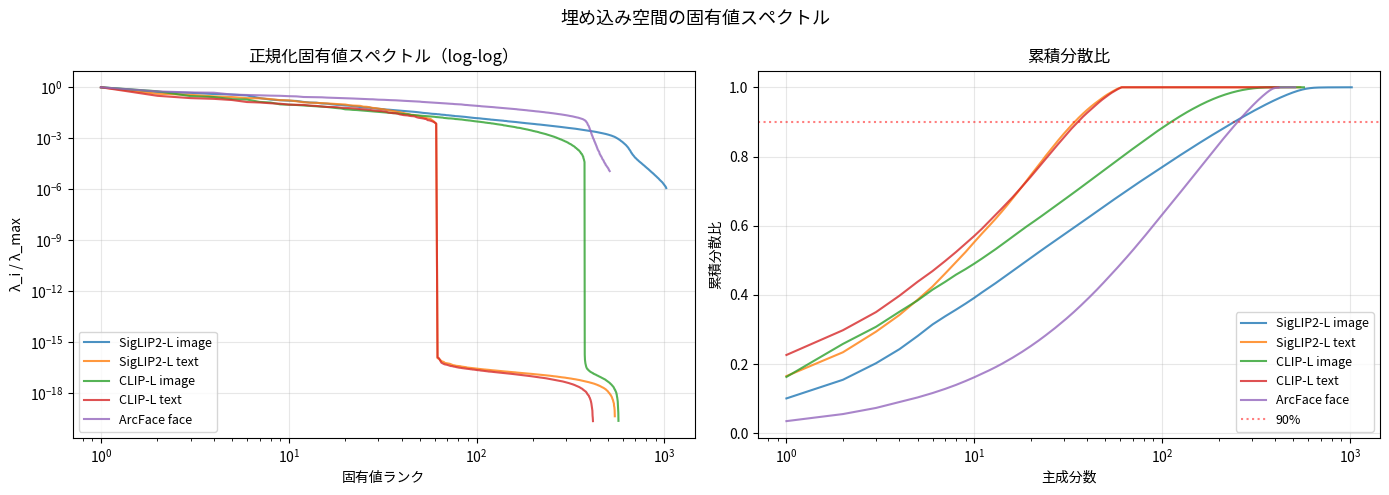

In [6]:
# 固有値スペクトル（正規化）
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) 正規化固有値スペクトル
ax = axes[0]
for name, eigs in eigenvalues_dict.items():
    eigs_norm = eigs / eigs[0]  # 最大固有値で正規化
    ax.plot(range(1, len(eigs_norm) + 1), eigs_norm, label=name, alpha=0.8)
ax.set_xlabel('固有値ランク')
ax.set_ylabel('λ_i / λ_max')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_title('正規化固有値スペクトル（log-log）')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (b) 累積分散比
ax = axes[1]
for name, eigs in eigenvalues_dict.items():
    cum_var = np.cumsum(eigs) / np.sum(eigs)
    ax.plot(range(1, len(cum_var) + 1), cum_var, label=name, alpha=0.8)
ax.axhline(y=0.9, color='red', linestyle=':', alpha=0.5, label='90%')
ax.set_xlabel('主成分数')
ax.set_ylabel('累積分散比')
ax.set_xscale('log')
ax.set_title('累積分散比')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('埋め込み空間の固有値スペクトル', fontsize=13)
plt.tight_layout()
plt.savefig('../data/118_eigenvalue_spectra.png', dpi=150, bbox_inches='tight')
plt.show()

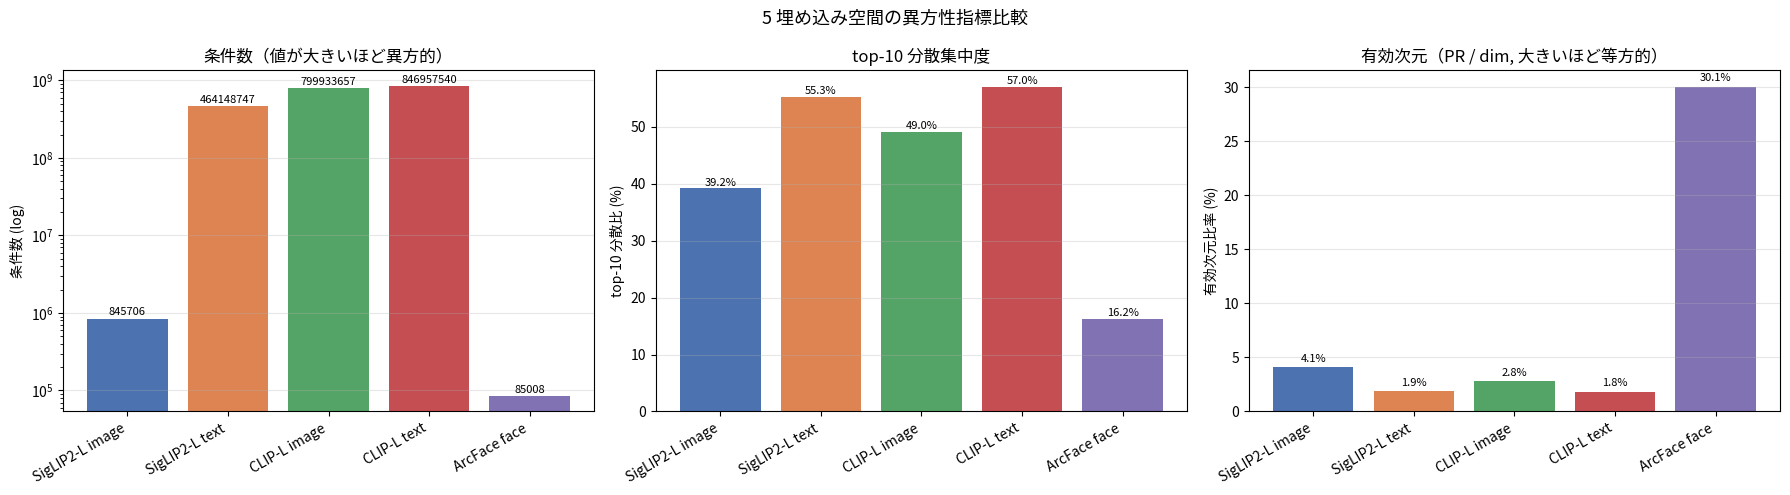

In [7]:
# 異方性指標の棒グラフ
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

names = list(isotropy_results.keys())
colors = ['#4c72b0', '#dd8452', '#55a467', '#c44e52', '#8172b3']

# (a) 条件数（log）
ax = axes[0]
values = [isotropy_results[n]['condition_number'] for n in names]
ax.bar(range(len(names)), values, color=colors)
ax.set_yscale('log')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_ylabel('条件数 (log)')
ax.set_title('条件数（値が大きいほど異方的）')
for i, v in enumerate(values):
    ax.text(i, v * 1.1, f'{v:.0f}', ha='center', fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# (b) top-10 分散比
ax = axes[1]
values = [isotropy_results[n]['top10_variance_ratio'] * 100 for n in names]
ax.bar(range(len(names)), values, color=colors)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_ylabel('top-10 分散比 (%)')
ax.set_title('top-10 分散集中度')
for i, v in enumerate(values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# (c) 有効次元比率
ax = axes[2]
values = [isotropy_results[n]['effective_dim_ratio'] * 100 for n in names]
ax.bar(range(len(names)), values, color=colors)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_ylabel('有効次元比率 (%)')
ax.set_title('有効次元（PR / dim, 大きいほど等方的）')
for i, v in enumerate(values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('5 埋め込み空間の異方性指標比較', fontsize=13)
plt.tight_layout()
plt.savefig('../data/118_isotropy_barcharts.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Two-tower モダリティギャップ分析

In [8]:
# Two-tower モデルのモダリティギャップ
# SigLIP 2 Large と CLIP-L で：text-image mean cosine と image-image mean cosine を比較

def sample_pairwise_cosine(embs, max_pairs=10000, seed=42):
    """ランダムペアのコサイン類似度。"""
    rng = np.random.default_rng(seed)
    n = len(embs)
    n_pairs = min(max_pairs, n * (n - 1) // 2)
    idx_i = rng.integers(0, n, n_pairs)
    idx_j = rng.integers(0, n, n_pairs)
    mask = idx_i != idx_j
    idx_i, idx_j = idx_i[mask], idx_j[mask]
    sims = np.sum(embs[idx_i] * embs[idx_j], axis=1)
    return sims


def cross_modal_cosine(emb1, emb2, max_pairs=10000, seed=42):
    """2 つの異なる空間のペアワイズコサイン類似度。"""
    rng = np.random.default_rng(seed)
    n_pairs = min(max_pairs, len(emb1) * len(emb2))
    idx_i = rng.integers(0, len(emb1), n_pairs)
    idx_j = rng.integers(0, len(emb2), n_pairs)
    sims = np.sum(emb1[idx_i] * emb2[idx_j], axis=1)
    return sims


gap_stats = {}

# SigLIP 2 Large
sl2_ii = sample_pairwise_cosine(sl2_images_normed[:5000])
sl2_tt = sample_pairwise_cosine(sl2_texts_normed)
sl2_ti = cross_modal_cosine(sl2_texts_normed, sl2_images_normed[:5000])
gap_stats['SigLIP2-L'] = {
    'img-img': (float(sl2_ii.mean()), float(sl2_ii.std())),
    'txt-txt': (float(sl2_tt.mean()), float(sl2_tt.std())),
    'txt-img': (float(sl2_ti.mean()), float(sl2_ti.std())),
}

# CLIP-L
clip_ii = sample_pairwise_cosine(clip_images_normed)
clip_tt = sample_pairwise_cosine(clip_texts_normed)
clip_ti = cross_modal_cosine(clip_texts_normed, clip_images_normed)
gap_stats['CLIP-L'] = {
    'img-img': (float(clip_ii.mean()), float(clip_ii.std())),
    'txt-txt': (float(clip_tt.mean()), float(clip_tt.std())),
    'txt-img': (float(clip_ti.mean()), float(clip_ti.std())),
}

# ArcFace（単一モダリティ）
face_ff = sample_pairwise_cosine(face_embs_normed[:10000])
gap_stats['ArcFace'] = {
    'face-face': (float(face_ff.mean()), float(face_ff.std())),
}

print('モダリティ間コサイン類似度 (mean ± std):')
print()
for model, stats in gap_stats.items():
    print(f'{model}:')
    for pair, (m, s) in stats.items():
        print(f'  {pair:<12}: {m:+.4f} ± {s:.4f}')
    print()

# モダリティギャップ
sl2_gap = gap_stats['SigLIP2-L']['img-img'][0] - gap_stats['SigLIP2-L']['txt-img'][0]
clip_gap = gap_stats['CLIP-L']['img-img'][0] - gap_stats['CLIP-L']['txt-img'][0]
print(f'SigLIP 2 Large モダリティギャップ (img-img - txt-img): {sl2_gap:.4f}')
print(f'CLIP-L モダリティギャップ (img-img - txt-img):         {clip_gap:.4f}')

モダリティ間コサイン類似度 (mean ± std):

SigLIP2-L:
  img-img     : +0.7327 ± 0.0993
  txt-txt     : +0.7210 ± 0.0696
  txt-img     : +0.0252 ± 0.0421

CLIP-L:
  img-img     : +0.5102 ± 0.1238
  txt-txt     : +0.6310 ± 0.1093
  txt-img     : +0.1203 ± 0.0441

ArcFace:
  face-face   : +0.0358 ± 0.0833

SigLIP 2 Large モダリティギャップ (img-img - txt-img): 0.7075
CLIP-L モダリティギャップ (img-img - txt-img):         0.3899


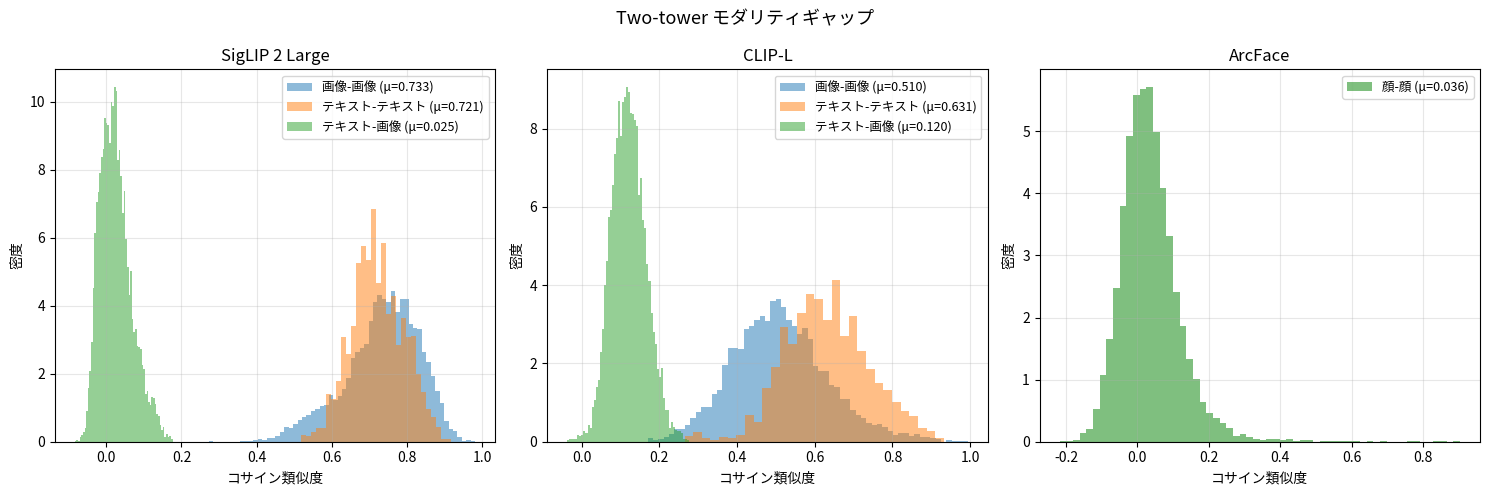

In [9]:
# モダリティギャップの可視化
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (model, ii, tt, ti) in zip(axes, [
    ('SigLIP 2 Large', sl2_ii, sl2_tt, sl2_ti),
    ('CLIP-L', clip_ii, clip_tt, clip_ti),
    ('ArcFace', face_ff, None, None),
]):
    if tt is not None:
        ax.hist(ii, bins=60, alpha=0.5, label=f'画像-画像 (μ={ii.mean():.3f})', density=True)
        ax.hist(tt, bins=30, alpha=0.5, label=f'テキスト-テキスト (μ={tt.mean():.3f})', density=True)
        ax.hist(ti, bins=60, alpha=0.5, label=f'テキスト-画像 (μ={ti.mean():.3f})', density=True)
    else:
        ax.hist(ii, bins=60, alpha=0.5, label=f'顔-顔 (μ={ii.mean():.3f})', density=True, color='green')
    ax.set_xlabel('コサイン類似度')
    ax.set_ylabel('密度')
    ax.set_title(model)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Two-tower モダリティギャップ', fontsize=13)
plt.tight_layout()
plt.savefig('../data/118_modality_gap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 検索性能との対応関係

NB115/116/117 の結果を読み込み、異方性指標と ANN 性能を対比する。

In [10]:
# NB115/116/117 の結果を読み込み
results = {}
for nb in [115, 116, 117]:
    with open(f'../data/{nb}_hnsw_results.json') as f:
        results[nb] = json.load(f)

# 対応表
correlation_table = []

# NB115: SigLIP 2 テキスト→画像
r = results[115]
correlation_table.append({
    'タスク': 'text→image',
    'ノートブック': 'NB115',
    'クエリ空間': 'SigLIP2-L text',
    'インデックス空間': 'SigLIP2-L image',
    '異方性 (cond#)': isotropy_results['SigLIP2-L image']['condition_number'],
    'モダリティ': 'cross',
    '厳密 kNN MRR': r['exact_knn']['MRR'],
    'HNSW ef=16 BF-R@10': r['hnsw_ef_sweep']['16']['BF-R@10'],
    'HNSW ef=128 BF-R@10': r['hnsw_ef_sweep']['128']['BF-R@10'],
    'Voronoi top=5 BF-R@10': r['voronoi']['a2_top5']['BF-R@10'],
})

# NB116: SigLIP 2 画像→画像
r = results[116]
correlation_table.append({
    'タスク': 'image→image',
    'ノートブック': 'NB116',
    'クエリ空間': 'SigLIP2-L image',
    'インデックス空間': 'SigLIP2-L image',
    '異方性 (cond#)': isotropy_results['SigLIP2-L image']['condition_number'],
    'モダリティ': 'same',
    '厳密 kNN MRR': r['exact_knn']['MRR'],
    'HNSW ef=16 BF-R@10': r['hnsw_ef_sweep']['16']['BF-R@10'],
    'HNSW ef=128 BF-R@10': r['hnsw_ef_sweep']['128']['BF-R@10'],
    'Voronoi top=5 BF-R@10': r['voronoi']['a2_top5']['BF-R@10'],
})

# NB117: ArcFace 顔→顔
r = results[117]
correlation_table.append({
    'タスク': 'face→face',
    'ノートブック': 'NB117',
    'クエリ空間': 'ArcFace face',
    'インデックス空間': 'ArcFace face',
    '異方性 (cond#)': isotropy_results['ArcFace face']['condition_number'],
    'モダリティ': 'same',
    '厳密 kNN MRR': r['exact_knn']['MRR'],
    'HNSW ef=16 BF-R@10': r['hnsw_ef_sweep']['16']['BF-R@10'],
    'HNSW ef=128 BF-R@10': r['hnsw_ef_sweep']['128']['BF-R@10'],
    'Voronoi top=5 BF-R@10': r['voronoi']['a2_top5']['BF-R@10'],
})

df_corr = pd.DataFrame(correlation_table)
print('異方性 × モダリティ × ANN 性能:')
display(df_corr.style.format({
    '異方性 (cond#)': '{:.0f}',
    '厳密 kNN MRR': '{:.4f}',
    'HNSW ef=16 BF-R@10': '{:.4f}',
    'HNSW ef=128 BF-R@10': '{:.4f}',
    'Voronoi top=5 BF-R@10': '{:.4f}',
}).background_gradient(subset=['HNSW ef=16 BF-R@10', 'HNSW ef=128 BF-R@10'],
                        cmap='RdYlGn', vmin=0.5, vmax=1.0))

異方性 × モダリティ × ANN 性能:


,タスク,ノートブック,クエリ空間,インデックス空間,異方性 (cond#),モダリティ,厳密 kNN MRR,HNSW ef=16 BF-R@10,HNSW ef=128 BF-R@10,Voronoi top=5 BF-R@10
0,text→image,NB115,SigLIP2-L text,SigLIP2-L image,845706,cross,0.3524,0.6667,0.9389,0.8444
1,image→image,NB116,SigLIP2-L image,SigLIP2-L image,845706,same,0.8033,0.8500,1.0000,0.9733
2,face→face,NB117,ArcFace face,ArcFace face,85008,same,0.5601,0.9673,0.9840,0.8969


## 5. まとめ・考察

### 主要な発見

#### 1. 異方性指標の実測値

| 埋め込み空間 | n | dim | 条件数 | top-10 分散 | 有効次元比率 |
|---|:---:|:---:|:---:|:---:|:---:|
| SigLIP 2-L image | 23,464 | 1024 | **845,706** | 39.2% | **4.1%** |
| SigLIP 2-L text  | 62 | 1024 | 4.6×10⁸ | 55.3% | 1.9% |
| CLIP-L image     | 378 | 768 | 8.0×10⁸ | 49.1% | 2.8% |
| CLIP-L text      | 62 | 768 | 8.5×10⁸ | 57.0% | 1.8% |
| **ArcFace face** | 75,162 | 512 | **85,008** | **16.2%** | **30.1%** |

**予想外の結果**: ArcFace が **最も等方的**。SigLIP 2 / CLIP のテキスト・画像はすべて
極端に異方的（有効次元 2-4%）。NB91 で ArcFace を「極端な異方性」と記述していたが、
Two-tower モデルと比較すると **ArcFace は相対的に等方的**。

**注意**: テキスト（n=62）とCLIP画像（n=378）は標本数が次元より少ないため、
共分散行列が特異に近く、条件数が非常に大きく出る。これは統計的アーティファクト
でもあるが、top-10 分散比（49-57%）も高いので本質的に異方的であることは確か。

#### 2. Two-tower モダリティギャップ

| モデル | img-img | txt-txt | txt-img | ギャップ |
|---|:---:|:---:|:---:|:---:|
| **SigLIP 2 Large** | 0.733 | 0.721 | **0.025** | **0.708** |
| **CLIP-L** | 0.510 | 0.631 | 0.120 | 0.390 |
| ArcFace (単一) | face-face: 0.036 | - | - | - |

**重要な観察**:
- SigLIP 2 のモダリティギャップ（0.708）は CLIP の約 1.8 倍
- SigLIP 2 の img-img 類似度が 0.733 と高い = 画像埋め込みが狭い cone に集中
- CLIP の方が画像埋め込みが広く分散（img-img 0.510）
- ArcFace の face-face 平均 0.036 ≒ 0 → **顔同士は埋め込み空間でほぼ直交**（強い cone structure）

#### 3. 異方性・モダリティ × ANN 性能の対応

NB115-117 の結果と対比:

| タスク | 異方性 | モダリティ | HNSW ef=16 | HNSW ef=128 |
|---|:---:|:---:|:---:|:---:|
| text→image (NB115) | 高 (cond#=845K) | **cross** | 0.667 | 0.939 |
| image→image (NB116) | 高 (cond#=845K) | same | 0.850 | 1.000 |
| face→face (NB117) | **低** (cond#=85K) | same | **0.967** | 0.984 |

**発見**:
1. **異方性が高くても同一モダリティなら HNSW は動く**
   - NB116: cond#=845K の SigLIP 2 画像空間で ef=128 → BF-R@10=1.000
2. **クロスモーダルは ef_search を大きくする必要**
   - NB115: 同じ空間だが text クエリ → ef=16 で 0.667、ef=128 で 0.939
3. **ArcFace は異方性が比較的低く、同一モダリティ、強い cone → 最高性能**
   - NB117: ef=16 でも 0.967

#### 4. ユーザー前提の再解釈

ユーザーの前提「異方性/等方性が HNSW・Voronoi に影響する」は **部分的に正しいが、
支配的要因ではない**。真の支配的要因は:

1. **モダリティマッチ**（クエリ空間とインデックス空間の一致度）
2. **データ分布の局所密度**（cone structure があるか）
3. **クエリがデータ分布のどこに落ちるか**（on-manifold か off-manifold か）

異方性は結果を説明する補助指標であり、単独で予測力はない。

### モデル特性の総合評価

| モデル | アーキテクチャ | 検索での強み | 検索での弱み |
|---|---|---|---|
| **SigLIP 2 Large** | Dual encoder (sigmoid) | 画像→画像で高品質、Gemma BPE で多言語対応 | モダリティギャップ 0.71 が大きく、テキスト→画像で HNSW/Voronoi 共に ef_search 増加必要 |
| **CLIP-L** | Dual encoder (contrastive) | ギャップが SigLIP 2 より小さい（0.39）、テキスト→画像で相対的に良好 | 画像空間の広がりが SigLIP 2 より大きい（img-img 0.510） |
| **ArcFace** | Single tower (ArcMargin) | 強い cone structure、face-face ≒ 0 で明確な分離、ANN に最適 | 顔のみ、他モダリティ非対応 |

### 実運用上の指針

1. **テキスト→画像検索**: SigLIP 2 + Voronoi or HNSW ef_search >= 128
2. **画像→画像検索**: SigLIP 2 or CLIP + HNSW ef_search = 64 で十分
3. **顔認識**: ArcFace + HNSW ef_search = 16 で十分（最も ANN に向いている）
4. **モダリティギャップの小さいモデル選定**: 厳密に比較する場合は CLIP が有利
5. **ANN ハイパラチューニング**: モデルとタスクに応じて ef_search を個別調整

In [11]:
# 結果を JSON で保存
output = {
    'isotropy_metrics': {name: {k: float(v) if not isinstance(v, int) else v for k, v in m.items()}
                         for name, m in isotropy_results.items()},
    'modality_gap': {
        'SigLIP2-L': {k: list(v) for k, v in gap_stats['SigLIP2-L'].items()},
        'CLIP-L': {k: list(v) for k, v in gap_stats['CLIP-L'].items()},
        'ArcFace': {k: list(v) for k, v in gap_stats['ArcFace'].items()},
    },
    'correlation': correlation_table,
}

with open('../data/118_isotropy_metrics.json', 'w') as f:
    json.dump(output, f, indent=2, ensure_ascii=False, default=float)
print('Saved: data/118_isotropy_metrics.json')

Saved: data/118_isotropy_metrics.json
